# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [7]:

dir = "./../../data/"
disk_name = "Simulated"
data_file = dir +"SimulatedCrescent.txt"

inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

# Load data
file = np.loadtxt(data_file, unpack =True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

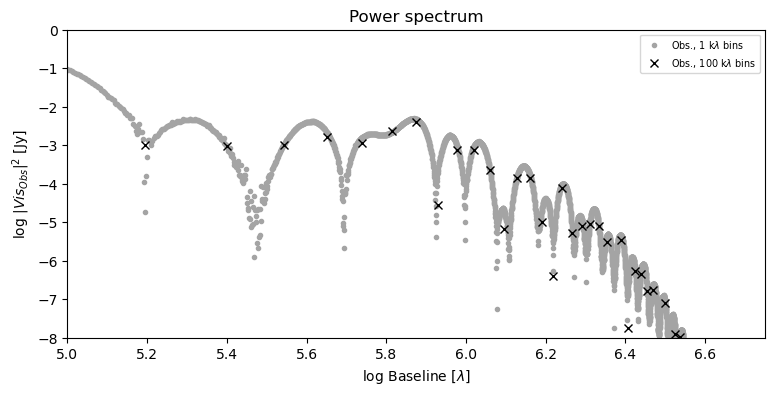

In [8]:
# Analize power spectrum.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))


cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(9, 4))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Power spectrum")
plt.ylim(-8, 0)
plt.xlim(5, 6.75)
plt.show()

### Dirty image

In [9]:
Rmax = 3*rout
Qmax = max(np.hypot(u,v))
N = 4*(Rmax/rad_to_arcsec)*Qmax

from math import ceil
N = ceil(N)


In [10]:
N

514

In [11]:
frank2d0 = Frank2D(N, Rmax)

In [12]:
frank2d0.process_vis(uvtable)

===>  Setting gridded data...


In [13]:
u, v = frank2d0.gridded_data['u'], frank2d0.gridded_data['v']
vis = frank2d0.gridded_data['vis']
weights = frank2d0.gridded_data['weights']

Text(0, 0.5, 'v [λ]')

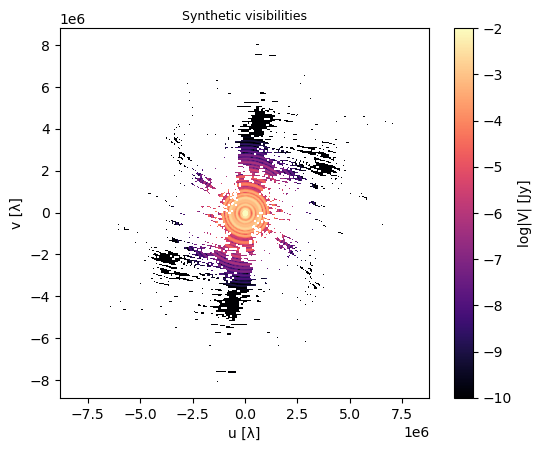

In [14]:
plt.imshow(np.log(np.abs(vis.reshape(N,N))), 
            extent = [u.min(), u.max(), v.min(), v.max()],
            cmap = 'magma', 
             vmin=-10, vmax=-2)

plt.colorbar(label='log|V| [Jy]')
plt.title('Synthetic visibilities', size=9)
plt.xlabel('u [λ]')
plt.ylabel('v [λ]')

In [15]:
dx = frank2d0.dx/rad_to_arcsec
dy = frank2d0.dy/rad_to_arcsec
pixel_area_in_sr = dx * dy
I_syn_full_Jy_per_sr = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis.reshape(N,N)))).real / pixel_area_in_sr
I_syn_full_Jy_per_pixel = I_syn_full_Jy_per_sr * pixel_area_in_sr

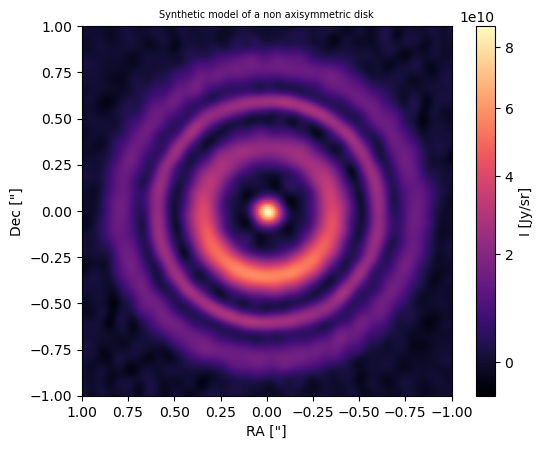

In [16]:
import matplotlib.colors as colors
norm = colors.PowerNorm(gamma = 0.7)

plt.imshow(
            I_syn_full_Jy_per_sr, 
            extent=[frank2d0.Rmax, -frank2d0.Rmax, -frank2d0.Rmax, frank2d0.Rmax],
            norm=norm, 
            cmap = 'magma'
            )

plt.gca().invert_yaxis()
plt.xlim(rout, -rout)
plt.ylim(-rout, rout)
plt.title('Synthetic model of a non axisymmetric disk', size =7)
plt.xlabel('RA ["]')
plt.ylabel('Dec ["]')
plt.colorbar(label='I [Jy/sr]')

## Frank2D

In [17]:
geom = Geometry(0, 0, 0, 0)

In [18]:
frank2d2 = Frank2D(N, Rmax)

In [19]:
frank2d2.fit(data = uvtable, rtol = 1e-10)

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2, 'c': 100000000.0, 'l': 50000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.04  min |  2.44 seconds
        +  Building system = 0.04  min |  2.50 seconds
===>  Solving linear system...
      .... iteration  0 :   actual tol  6.85e+08  versus  6.85e-02
      .... iteration  10 :   actual tol  3.62e+07  versus  6.85e-02
      .... iteration  20 :   actual tol  1.33e+07  versus  6.85e-02
      .... iteration  30 :   actual tol  4.56e+06  versus  6.85e-02
      .... iteration  40 :   actual tol  1.42e+07  versus  6.85e-02
      .... iteration  50 :   actual tol  2.01e+06  versus  6.85e-02
      .... iteration  60 :   actual tol  1.88e+05  versus  6.85e-02
      .... iteration  70 :   actual tol  1.32e+05  versus  6.85e-02
      .... iteration  80 :   actual tol  5.84e+04  versus  6.85e-02
      .... iteration  90 :   actual tol  2.23e+04  versus  6.85e-02
      .... itera

In [20]:
Plot_ = Plot(frank2d2, geom)

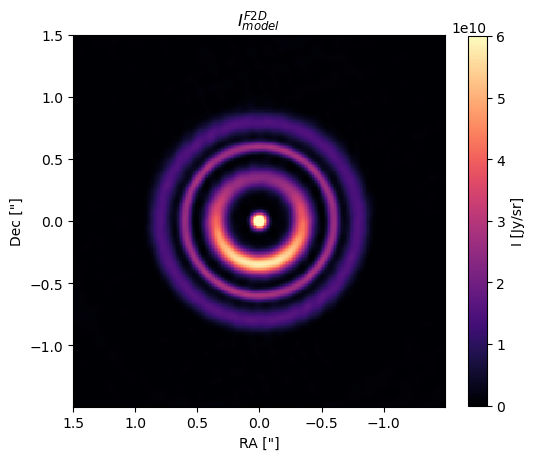

In [21]:
Plot_.intensity(vmax=6e10, gamma = 1, zoom = 2, title = r'$I_{model}^{F2D}$')

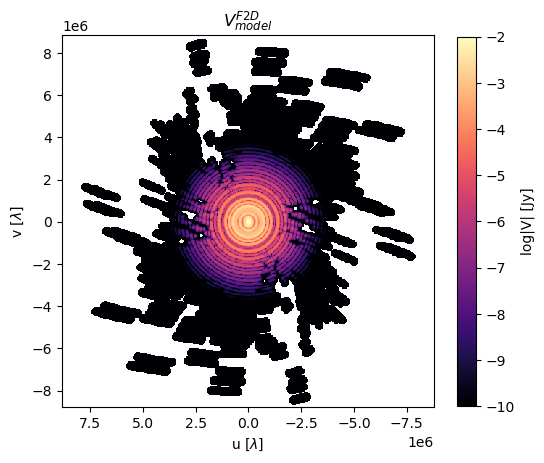

In [22]:
Plot_.visibility(fig_size=6, title= r'$V_{model}^{F2D}$')

###  Best

In [23]:
initial_guess = {'m': -1, 'logl': 4}

In [24]:
frank2d2.search_MAP(initial_guess= initial_guess, N = 50)

Using existing visibility data...
!!!!!!!!! 1215427.0268120933
Fitting the visibilities with Frank2D with 2DFT...


 + Time to preprocess the visibilities: 209.80 seconds
Setting the initial guess...
Optimizing the posterior...


KeyboardInterrupt: 

In [ ]:
frank2d2.MAP

{'m': -1.0068828169746133, 'c': 958.7695072254294, 'l': 72532.08123620044}

In [29]:
best_N50 = {'m': -0.6243821404369595, 'c': 2.04168129696841, 'l': 71124.26421422759}

In [30]:
best_N60 = {'m': -1.995082249593998, 'c': 8501943831.276791, 'l': 57461.09572521277}

### Frank2D with best values

In [31]:
frank2d3 = Frank2D(N, Rmax)

In [32]:
frank2d3.fit(data = uvtable, kernel_params = best_N50, rtol = 1e-8) # 1m7s

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -0.6243821404369595, 'c': 2.04168129696841, 'l': 71124.26421422759}
===>  Creating sparse linear system...
        +  Kernel = 0.05  min |  3.23 seconds
        +  Building system = 0.06  min |  3.34 seconds
===>  Solving linear system...
      .... iteration  0 :   actual tol  7.44e+08  versus  7.44e+00
      .... iteration  10 :   actual tol  5.01e+07  versus  7.44e+00
      .... iteration  20 :   actual tol  2.64e+07  versus  7.44e+00
      .... iteration  30 :   actual tol  2.15e+07  versus  7.44e+00
      .... iteration  40 :   actual tol  1.85e+07  versus  7.44e+00
      .... iteration  50 :   actual tol  9.93e+06  versus  7.44e+00
      .... iteration  60 :   actual tol  6.94e+06  versus  7.44e+00
      .... iteration  70 :   actual tol  6.70e+06  versus  7.44e+00
      .... iteration  80 :   actual tol  4.65e+06  versus  7.44e+00
      .... iteration  90 :   actual tol  2.65e+06  v

In [69]:
Plot_3 = Plot(frank2d3, geom)

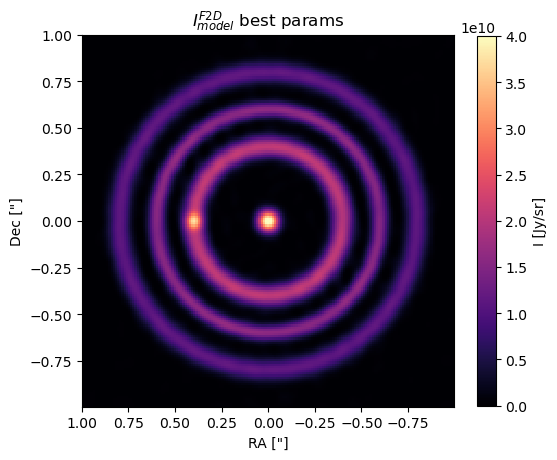

In [74]:
Plot_3.intensity(vmax=4e10,  gamma = 1, zoom=3, title = r'$I_{model}^{F2D}$ best params')

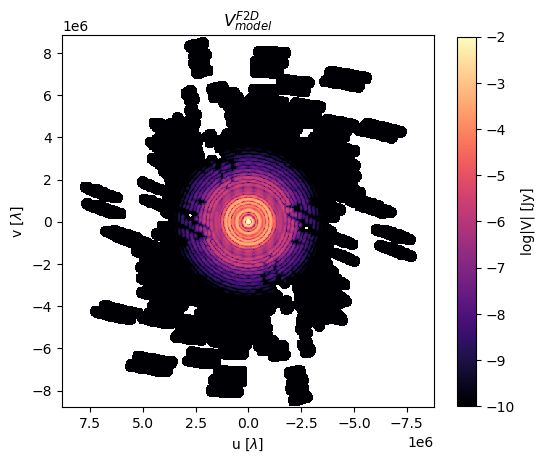

In [72]:
Plot_3.visibility(fig_size=6)